### Artificial Intelligence 601.464 Project #5

#### Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.

#### General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing.

#### Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

### Part 0: Conda Imports

We will be using non-standard libaries for this assignment. 
- **pandas** for working with tabular data
- **scikit-learn** for data preprocessing
- **torch** for building NNs
- **tqdm** for progress bar
- **shap** for explainable AI 


***Installing Imports***

To ensure consistency with outputs, we recommend using a python environment to install these libraries. We recommend using conda. Miniconda is sufficient: https://www.anaconda.com/docs/getting-started/miniconda/main

Once conda is installed, create your own environment by running:

```conda create -n "ai_hw4" python=3.11```

To install your libraries:

```
conda activate "ai_hw4"
pip install pandas scikit-learn torch tqdm shap ipykernel
```

Now we select our "ai_hw4" kernel when running our code and we have a consistent python run!

### Part 1: Neural Networks: Architecture

For this assignment we will explore Neural Networks; in particular, we are going to explore model complexity. The goal is classify a mushroom as either edible ('e') or poisonous ('p'). The dataset has been uploaded to Canvas. In case you'd like to learn more about it, here's the link to the repo: https://archive.ics.uci.edu/dataset/73/mushroom. Use PyTorch (https://pytorch.org/) to explore different model complexities (i.e., architectures) before declaring a winner. Either start with a simple network and make it more complex; or start with a complex model and pare it down. Either way, your submission should clearly demonstrate your exploration.

More specifically:

* Try three different models,
* <font color="red">**Use K-Folds cross validation to compare the models**,</font>
* Report the winning model's performance on test data (this is the only time you will use test data),
* Include a table comparing the three models,
* Document your process: what the results were, how the winning model was determined, loss function, activation, etc.

Information on cross validation: https://scikit-learn.org/stable/modules/cross_validation.html (notice how final evaluation is the only time test data is used). No other directions for this assignment other than what's here and in the "General Directions" section. You have a lot of freedom with this assignment. Don't get carried away. It is expected the results may vary, being better or worse, due to the limitations of the dataset. Graders are not going to run your notebooks. The notebook will be read as a report on how different models were explored. Since you'll be using libraries, the emphasis will be on your ability to communicate your findings.

### Model Analysis
**Implementation, exploration, findings go here:**

In [105]:
# Imports
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [106]:
# Reads in data and assigns features and labels to x and y, respectively 
df = pd.read_csv("/home/jason-lafita/ai_projects/project_5/agaricus-lepiota.data")
y = df.iloc[:, 0]
X = df.iloc[:, 1:]

In [107]:
# Preprocesses and splits data
encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)
y = (y == 'p').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)

y_train = torch.tensor(y_train.to_numpy().copy(), dtype=torch.float32).view(-1, 1)
y_test  = torch.tensor(y_test.to_numpy().copy(), dtype=torch.float32).view(-1, 1)

device = torch.device("cpu")

In [108]:
# Training function

def train_model(model, X_tr, y_tr, X_val, y_val, epochs=20):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        preds = model(X_tr)
        loss = criterion(preds, y_tr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val)

            predicted = (val_preds > 0.5).float()
            acc = (predicted == y_val).float().mean().item()

        val_losses.append(val_loss.item())
        val_accuracies.append(acc)

    return train_losses, val_losses, val_accuracies

In [109]:
# Uses k-folds to evaluated the models

def evaluate_model(ModelClass, kf, input_size):
    fold_accuracies = []

    last_train_losses = None
    last_val_losses = None
    last_val_accs = None

    for i, (train_idx, val_idx) in enumerate(kf.split(X_train)):

        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]
        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        model = ModelClass(input_size)

        train_losses, val_losses, val_accs = train_model(
            model, X_tr, y_tr, X_val, y_val
        )

        fold_accuracies.append(val_accs[-1])  # final epoch accuracy

        # save last fold
        if i == kf.get_n_splits() - 1:
            last_train_losses = train_losses
            last_val_losses = val_losses
            last_val_accs = val_accs

    avg_acc = sum(fold_accuracies) / len(fold_accuracies)

    return avg_acc, last_train_losses, last_val_losses, last_val_accs

In [110]:
# Model 1: Low complexity

class Model1(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [111]:
# Model 2: Medium complexity

class Model2(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [112]:
# Model 4: High complexity

class Model3(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [113]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_size = X_encoded.shape[1]

acc1, train1, val1, accs1 = evaluate_model(Model1, kf, input_size)
acc2, train2, val2, accs2 = evaluate_model(Model2, kf, input_size)
acc3, train3, val3, accs3 = evaluate_model(Model3, kf, input_size)

In [114]:
# Prints results as a table

results = pd.DataFrame({
    "": ["Train Accuracy"],
    "Model 1": [acc1],
    "Model 2": [acc2],
    "Model 3": [acc3]
}).round(4)

results

,,Model 1,Model 2,Model 3
0,Train Accuracy,0.8955,0.864,0.8949


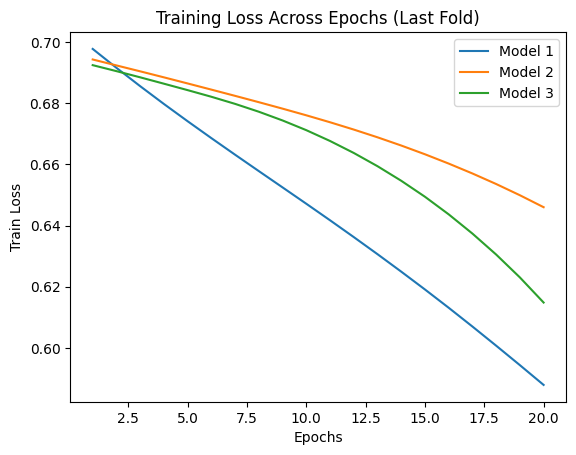

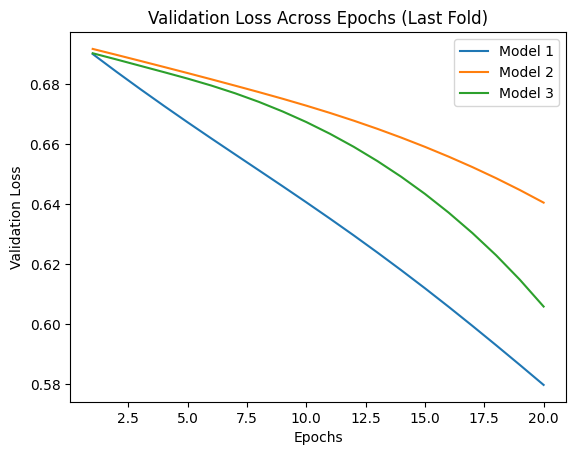

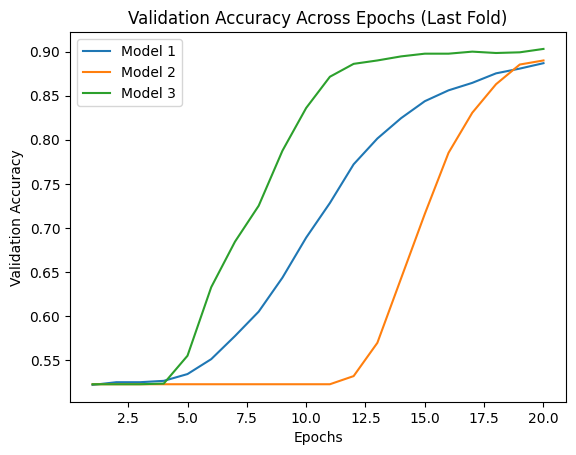

In [115]:
# Makes three plots,

epochs = range(1, len(train1) + 1)

# Train Loss
plt.figure()
plt.plot(epochs, train1, label="Model 1")
plt.plot(epochs, train2, label="Model 2")
plt.plot(epochs, train3, label="Model 3")
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.title("Training Loss Across Epochs (Last Fold)")
plt.legend()
plt.show()

# Validation loss
plt.figure()
plt.plot(epochs, val1, label="Model 1")
plt.plot(epochs, val2, label="Model 2")
plt.plot(epochs, val3, label="Model 3")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Epochs (Last Fold)")
plt.legend()
plt.show()

# Validation accuracy
plt.figure()
plt.plot(epochs, accs1, label="Model 1")
plt.plot(epochs, accs2, label="Model 2")
plt.plot(epochs, accs3, label="Model 3")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Epochs (Last Fold)")
plt.legend()
plt.show()

In [116]:
# Picks and performs final evaluations on model 3 (consistently the highest-accuracy, lowest loss model)
best_model = Model3(input_size)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(best_model.parameters(), lr=0.001)

for epoch in range(20):
    preds = best_model(X_train)
    loss = criterion(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

best_model.eval()
with torch.no_grad():
    preds = best_model(X_test)
    predicted = (preds > 0.5).float()
    test_acc = (predicted == y_test).float().mean().item()

print("Test Accuracy:", test_acc)

Test Accuracy: 0.907076895236969


**Document your process**: what the results were, how the winning model was determined, loss function, activation, etc:

I used Torch neural networks to implement three fairly simple models, wherein I varied the parameters of each upon creation to increase the complexity. Model 1 has 1 hidden layer, model 2 has 2 hidden layers, and model 3 has 3 hidden layers, increasing from very shallow to deeper. I used one hot encoding for categorical features to get a high dimensional input space. I then split the data into training and test sets.

To compare models, I used 5-fold cross-validation. This allowed for each model to be evaluated across multiple data splits to really get a sense of which model is consistently the most accurate.

Model Architectures
Model 1 (Low Complexity):
1 hidden layer (16 units, ReLU)
Model 2 (Medium Complexity):
2 hidden layers (32 → 16 units, ReLU)
Model 3 (High Complexity):
3 hidden layers (64 → 32 → 16 units, ReLU)

Activation: Sigmoid activation in the output layer
Loss: Binary Cross Entropy Loss
Optimization: Adam optimizer with learning rate 0.001

I ran the models on the trianing data multiple times, and Model 3, with the highest complexity, was consistently the most accurate, so I determined it to be the best model, which I used for the final evaluation on the test data.

### Part 2: Neural Networks: SHAP Analysis

Use the SHAP framework to understand how you best perfoming neural network makes decisions.

Use the documentation (https://shap.readthedocs.io/en/latest/index.html) as guide to analyze your neural network.

In [117]:
# Code goes here!
# Show a graph for magnitude of SHAP values!

- What is the feature with the highest average magnitude? 
- What is the feature with the lowest average magnitude?

<font color="red">*Your Answer goes here*</font>

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
02.  Do not submit any other files.